In [1]:
import numpy as np
import glob, os
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
base_dict = {"VAE_RMSD": None,
             "VAE_LOSS_RMSD": None,
             "PCA_RMSD": None,
             "PCA_LOSS_RMSD": None}

def load_files(numpy_files, verbose=True):
    fns = sorted(numpy_files)
    attrs = [fn.split('/') for fn in fns]
    model_name = attrs[0][0]
    assert False not in [elem[0] == model_name for elem in attrs]
    
    model_data = {}
    for attr_set in attrs:
        n_latents = int(attr_set[1].split('_')[0])
        if n_latents not in model_data.keys():
            model_data[n_latents] = {}
        rpt = attr_set[2]
        if rpt not in model_data[n_latents].keys():
            model_data[n_latents][rpt] = deepcopy(base_dict)

        try:
            if attr_set[-1].split('.')[0] in [key for key in base_dict.keys()]:
                model_data[n_latents][rpt][attr_set[-1].split('.')[0]] = np.load(os.path.join(*attr_set))
            else:
                if verbose:
                    print(f"Excluding ", os.path.join(*attr_set))
        except:
            if verbose:
                    print(f"Failure on", os.path.join(*attr_set))
            
    return model_data

def lowest_rpts(chart_data):
    means = {}

    for key, val in chart_data.items():
        if key not in means.keys():
            means[key] = {}
        for key2, val2 in chart_data[key].items():
            if key2 not in means[key].keys():
                means[key][key2] = {}
            for key3, val3 in chart_data[key][key2].items():
                means[key][key2][key3] = np.mean(chart_data[key][key2][key3])
    
    best_rpts_RMSD = {key: None for key in means.keys()}
    best_rpts_LOSS = {key: None for key in means.keys()}
    
    for key, val in means.items():
        #discover the lowest mean rpt
        best_rpts_RMSD[key] = min(val.items(), key=lambda x: x[-1]['VAE_RMSD'])[0]
        best_rpts_LOSS[key] = min(val.items(), key=lambda x: x[-1]['VAE_LOSS_RMSD'])[0]
    
    return means, best_rpts_RMSD, best_rpts_LOSS

In [8]:
#Plot Violin of the best

def violin_plots(vae_dat, pca_dat, latents, title, ceil=5.0):
    import matplotlib.pyplot as plt
    
    plt.clf()
    fig = plt.figure(figsize=(3.25, 3.25))
    #rmsds and pca rmsds are a dict of results with keys n_latent and vals hist_vals
    rpt_rmsds = [10*vae_dat[key] for key in vae_dat.keys()] #convert to angstrom
    rpt_pca_rmsds = [10*pca_dat[key] for key in pca_dat.keys()] #convert to angstrom
    
    max_rmsd = np.max([np.max(rmsd_set) for rmsd_set in rpt_rmsds])
    if max_rmsd < ceil:
        ceil = max_rmsd + 0.1*max_rmsd
    
    v1 = plt.violinplot(rpt_rmsds, [np.log2(n)-0.05 for n in latents], showextrema=False)
    v2 = plt.violinplot(rpt_pca_rmsds, [np.log2(n)+0.05 for n in latents], showextrema=False)

    num_above = [val_set[np.where(val_set > ceil)].shape for val_set in rpt_rmsds]
    print(num_above)
    for i, b in enumerate(v1['bodies']):
        if not np.all(np.isnan(rpt_rmsds[i])):
            b.set_edgecolor('black')
            b.set_alpha(1)
            # get the center (the center is actually the domain point)
            m = np.mean(b.get_paths()[0].vertices[:, 0])
            # modify the paths to not go further right than the center
            b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
            b.set_color('r')
        else:
            plt.vlines(np.log2(latents[i])-0.05,
                       ymin=0.1,
                       ymax=ceil-1,
                       colors='red', linestyles='dashed')
            print(f'ALL VALUES ARE NAN FOR {latents[i]} LATENTS!')
    
    for b in v2['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further left than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)
        b.set_color('b')
    
    plt.xlabel('N Latents (log2)')
    plt.ylabel('Reconstruction Error (Angstrom)')
    plt.title(title)
    plt.ylim(0, ceil)
    plt.savefig(os.path.join(figure_dir, f'reconstruction_rmsd_{title=}.png'), bbox_inches='tight')

In [9]:
def title_of_model(name):
    if name.startswith('OX_X'):
        return 'Oxycodone'
    elif name.startswith('DA_X'):
        return 'Deca-Alanine'
    elif name.startswith('DA_stretch'):
        return 'Deca-Alanine Helix Stretch'
    elif name.startswith('CR_X'):
        return 'Crambin'
    elif name.startswith('BR_X'):
        return 'BRD4/JQ1'
    elif name.startswith('HIV1p_X'):
        return 'HIV1-Protease'
    elif name.startswith('KOR_X'):
        return 'KOR/ak'
    else:
        raise Exception(f'No title found for {name}!')

In [10]:
base_models = [f'X009-{i}' for i in range(1, 7)]
model_prefixes = ['OX_', 'DA_', 'CR_', 'BR_']

OX_X009-1
[(0,), (0,), (0,), (0,), (0,), (0,)]
DA_X009-1
[(0,), (0,), (0,), (0,), (0,), (0,), (0,)]
CR_X009-1


/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 327 LATENTS!
BR_X009-1
[(7,), (6,), (1,), (8,), (8,), (8,), (8,), (8,), (8,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 512 LATENTS!
ALL VALUES ARE NAN FOR 1024 LATENTS!
ALL VALUES ARE NAN FOR 1093 LATENTS!
OX_X009-2
[(0,), (0,), (0,), (0,), (0,), (0,), (0,)]
DA_X009-2
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (13,)]
CR_X009-2
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 256 LATENTS!
ALL VALUES ARE NAN FOR 512 LATENTS!
ALL VALUES ARE NAN FOR 642 LATENTS!
BR_X009-2
[(10,), (14,), (8,), (8,), (9,), (8,), (8,), (0,), (0,), (0,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 128 LATENTS!
ALL VALUES ARE NAN FOR 256 LATENTS!
ALL VALUES ARE NAN FOR 512 LATENTS!
ALL VALUES ARE NAN FOR 1024 LATENTS!
ALL VALUES ARE NAN FOR 2048 LATENTS!
ALL VALUES ARE NAN FOR 2178 LATENTS!
OX_X009-3
[(0,), (0,), (0,), (0,), (0,), (0,)]
DA_X009-3
[(0,), (0,), (0,), (0,), (0,), (0,), (0,)]
CR

/var/tmp/ipykernel_24267/4111214697.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(3.25, 3.25))


[(8,), (8,), (5,), (8,), (8,), (8,), (8,), (0,), (0,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 128 LATENTS!
ALL VALUES ARE NAN FOR 256 LATENTS!
ALL VALUES ARE NAN FOR 512 LATENTS!
ALL VALUES ARE NAN FOR 1024 LATENTS!
ALL VALUES ARE NAN FOR 1093 LATENTS!
OX_X009-6
[(0,), (0,), (0,), (0,), (0,), (0,)]
DA_X009-6
[(0,), (0,), (0,), (0,), (0,), (0,), (0,)]
CR_X009-6
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 327 LATENTS!
BR_X009-6
[(0,), (8,), (8,), (6,), (8,), (8,), (8,), (8,), (0,), (0,), (0,), (0,)]
ALL VALUES ARE NAN FOR 256 LATENTS!
ALL VALUES ARE NAN FOR 512 LATENTS!
ALL VALUES ARE NAN FOR 1024 LATENTS!
ALL VALUES ARE NAN FOR 1093 LATENTS!


...

<Figure size 325x325 with 0 Axes>

<Figure size 325x325 with 0 Axes>

<Figure size 325x325 with 0 Axes>

<Figure size 325x325 with 0 Axes>

<Figure size 325x325 with 0 Axes>

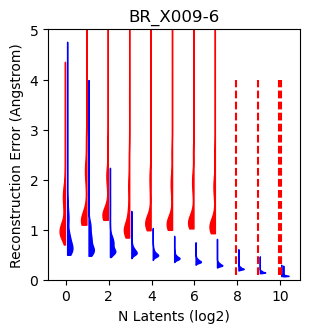

In [11]:
for base_model in base_models:
    for model_pre in model_prefixes:
        model_name2load = model_pre + base_model
        print(model_name2load)
        chart_data = load_files(glob.glob(f'{model_name2load}/*/*/*.npy'), verbose=False)
        means, best_rpts_rmsd, best_rpts_loss = lowest_rpts(chart_data)
        
        vae_rmsds =      {key: val[best_rpts_rmsd[key]]['VAE_RMSD']      for key, val in chart_data.items()}
        vae_loss_rmsds = {key: val[best_rpts_loss[key]]['VAE_LOSS_RMSD'] for key, val in chart_data.items()}
        pca_rmsds =      {key: val[best_rpts_rmsd[key]]['PCA_RMSD']      for key, val in chart_data.items()}
        pca_loss_rmsds = {key: val[best_rpts_loss[key]]['PCA_LOSS_RMSD'] for key, val in chart_data.items()}
        
        latents = [int(key) for key in vae_rmsds]
    
        figure_dir = os.path.join(os.getcwd(), f'figures/{model_name2load}/')
        if not os.path.isdir(figure_dir):
            os.makedirs(figure_dir, exist_ok=True)
        try:
            violin_plots(vae_rmsds, pca_rmsds, latents, model_name2load)
        except:
           print(f"Error Producing Plots on {model_name2load}")